In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Question 1 — Intensity transformations on `runway.png`

- **(a)** Gamma correction with $\gamma = 0.5$
- **(b)** Gamma correction with $\gamma = 2$
- **(c)** Contrast stretching: $r \in [0,1]$, $r_1=0.2$, $r_2=0.8$

$$
s(r) = \begin{cases}
0, & r < r_1 \\
\frac{r - r_1}{r_2 - r_1}, & r_1 \le r \le r_2 \\
1, & r > r_2
\end{cases}
$$

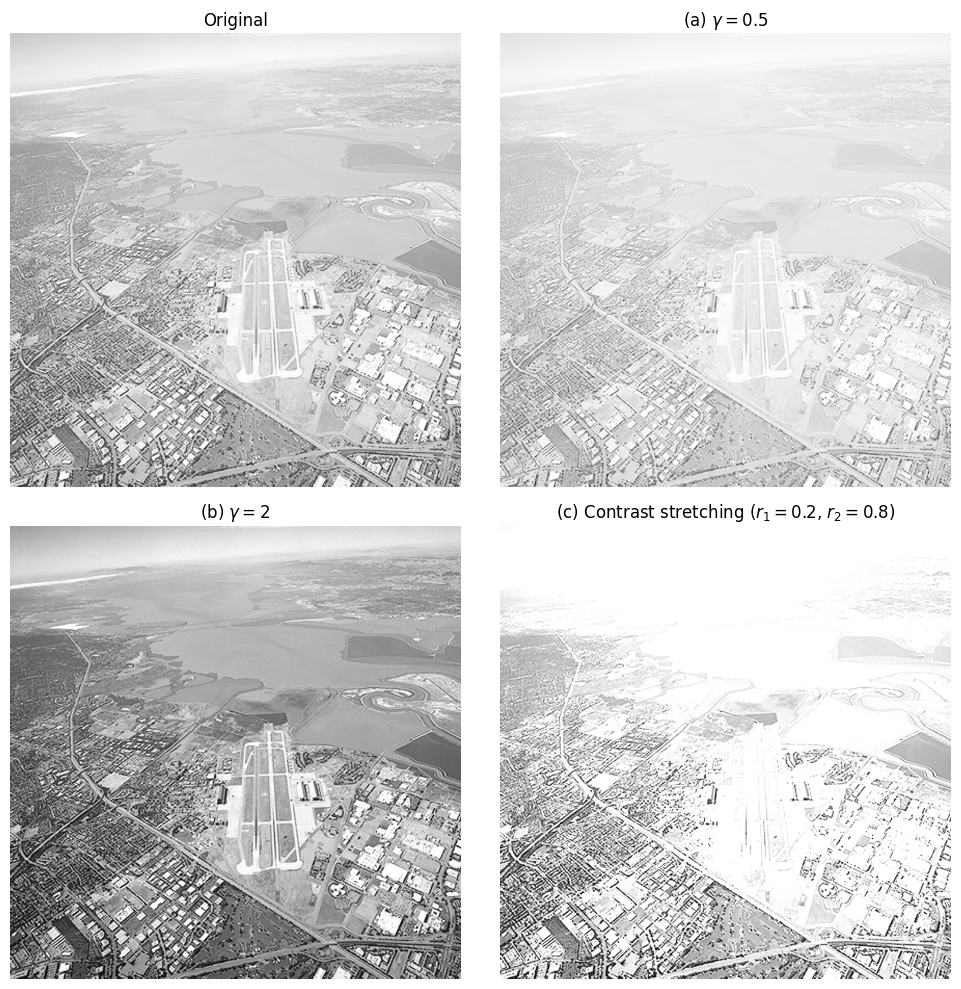

In [4]:
# Load image (BGR from OpenCV → RGB for display)
img_bgr = cv2.imread("images/runway.png")
if img_bgr is None:
    raise FileNotFoundError("Could not read images/runway.png — check path and filename (e.g. runway vs runaway).")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# Normalized intensities in [0, 1] (per channel)
r = img_rgb.astype(np.float64) / 255.0


def to_uint8(x: np.ndarray) -> np.ndarray:
    return np.clip(np.round(x * 255.0), 0, 255).astype(np.uint8)


def gamma_correct(x: np.ndarray, gamma: float) -> np.ndarray:
    return np.clip(x ** gamma, 0.0, 1.0)


def contrast_stretch_piecewise(x: np.ndarray, r1: float = 0.2, r2: float = 0.8) -> np.ndarray:
    s = np.zeros_like(x)
    low = x < r1
    mid = (x >= r1) & (x <= r2)
    high = x > r2
    s[low] = 0.0
    s[mid] = (x[mid] - r1) / (r2 - r1)
    s[high] = 1.0
    return s


out_gamma_05 = to_uint8(gamma_correct(r, 0.5))
out_gamma_2 = to_uint8(gamma_correct(r, 2.0))
out_stretch = to_uint8(contrast_stretch_piecewise(r, 0.2, 0.8))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original")
axes[0, 1].imshow(out_gamma_05)
axes[0, 1].set_title(r"(a) $\gamma = 0.5$")
axes[1, 0].imshow(out_gamma_2)
axes[1, 0].set_title(r"(b) $\gamma = 2$")
axes[1, 1].imshow(out_stretch)
axes[1, 1].set_title("(c) Contrast stretching ($r_1=0.2$, $r_2=0.8$)")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()